In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
RUN_ID = 'cooking'
DT = 1
Q0 = 17921.57581 
SAVE  = False
ITS = int(10e3)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.1
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [3]:
model_name = '0509_2355_b4_combo_full_combo_V-dynamic_F-dynamic_399.39min_16h_1500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)
display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 constrained to [0.005, 0.25] Ohm
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.005007,16673.537109,0.013979,0.032191,0.000000,0.000023
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.005007,16673.406250,0.013978,0.032192,0.000023,0.000023
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.005007,16673.279297,0.013976,0.032192,0.000045,0.000023
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.005007,16673.154297,0.013975,0.032193,0.000068,0.000023
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.005007,16673.029297,0.013974,0.032193,0.000090,0.000023
...,...,...,...,...,...,...,...,...,...,...,...,...
209564,124,5.00,0.0,24.891078,0.000000,0.233333,0.248848,2362.500977,0.007377,0.024174,0.272066,0.000497
209565,124,5.00,0.0,24.891078,0.000000,0.231944,0.248900,2334.054932,0.007362,0.024177,0.272563,0.000497
209566,124,5.00,0.0,24.891078,0.000000,0.230556,0.248954,2306.782715,0.007348,0.024180,0.273060,0.000497
209567,124,5.00,0.0,24.891078,0.000000,0.229167,0.249009,2280.636963,0.007335,0.024182,0.273557,0.000497


In [4]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [5]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


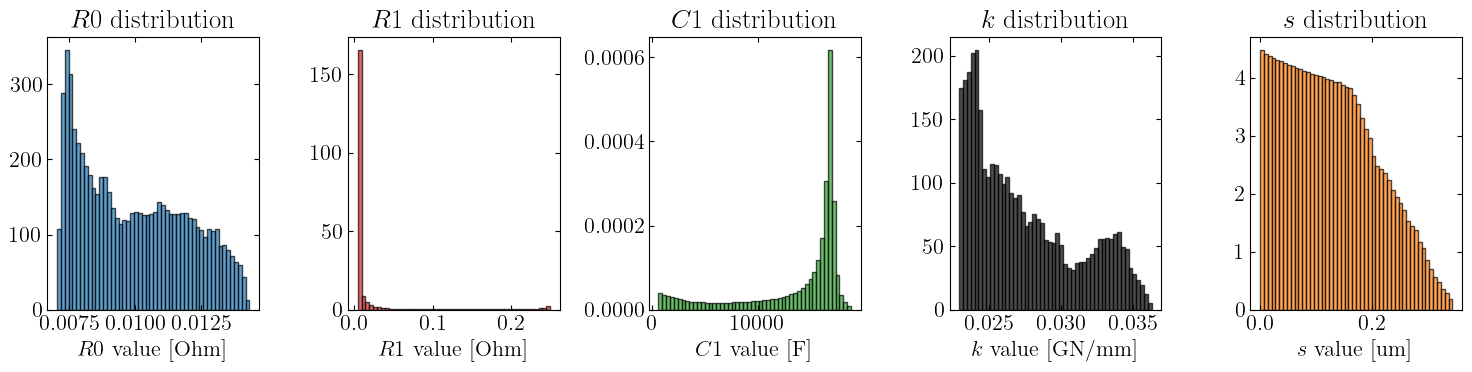

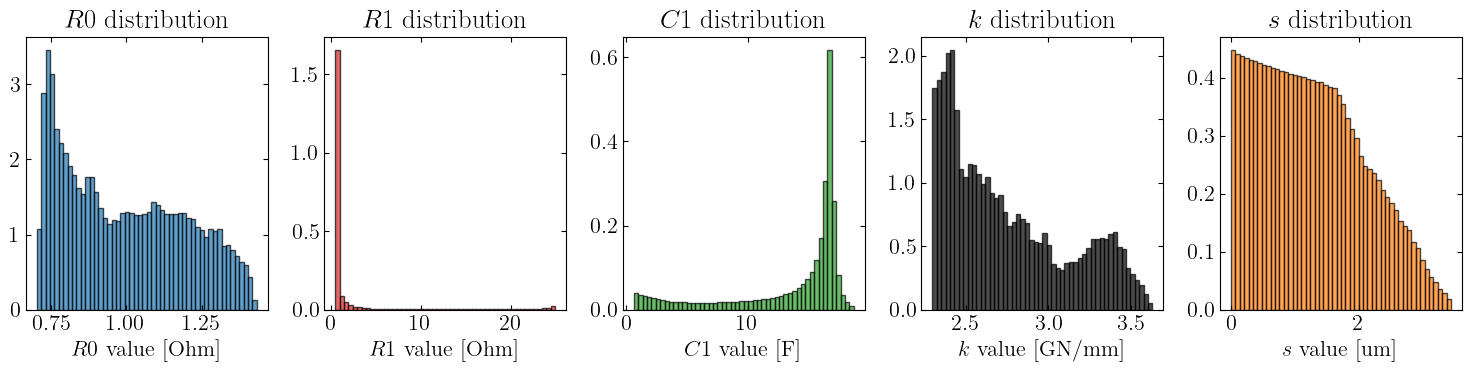

In [6]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [7]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['s'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [8]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 4th data point for symbolic regression, total points: 48455
Using every 1th data point for symbolic regression, total points: 15749


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.04195296
Equation: 0.99831975

Model 1: Complexity=5, Loss=0.022439418
Equation: -1.7818279 / (x2 + -2.3647947)

Model 2: Complexity=7, Loss=0.012917795
Equation: x2 + sqrt(0.08228673 / x2)

Model 3: Complexity=9, Loss=0.009952077
Equation: sqrt(square(x2 - 0.3875305)) + 0.74086195

Model 4: Complexity=11, Loss=0.007981982
Equation: (x2 + ((0.020006241 / x0) ^ x2)) * 1.3763031

Model 5: Complexity=13, Loss=0.007120933
Equation: ((0.014846904 ^ x2) + x2) * (1.5046393 - (x0 * 0.07509895))

Model 6: Complexity=15, Loss=0.006243775
Equation: (((0.4029037 / ((x1 + 9.691) * x0)) ^ x2) + x2) * 1.3678769

Model 7: Complexity=17, Loss=0.005325011
Equation: ((4.963015 / (x0 * (x1 + 18.162857))) + 1.2232885) * ((0.015236433 ^ x2) + x2)

Model 8: Complexity=19, Loss=0.005211526
Equation: ((0.8431418 / ((1.0356212 ^ x1) + x0)) + 1.0867418) * ((0.015236433 ^ x2) + x2)

Model 9: Complexity=21, Loss=0.00440296
Equation: (x1 * -0.004808117) + sqrt(sqrt(((x2 ^ x2) + -0.6524

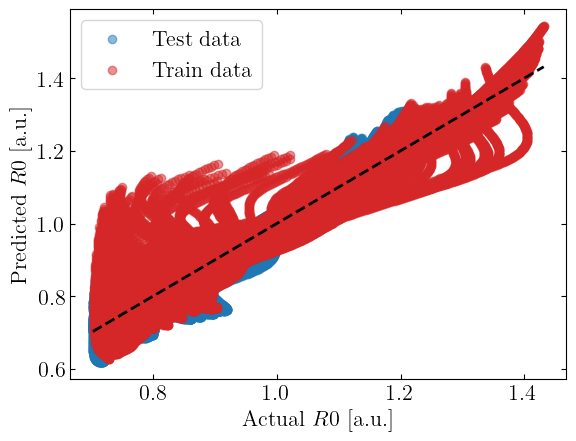

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: -0.004808117*x1 + ((7.2839613 + 5.6262617/x0)*(x2**x2 - 0.65242445))**(1/4)
Loss: 0.00440296
Best model complexity: 21


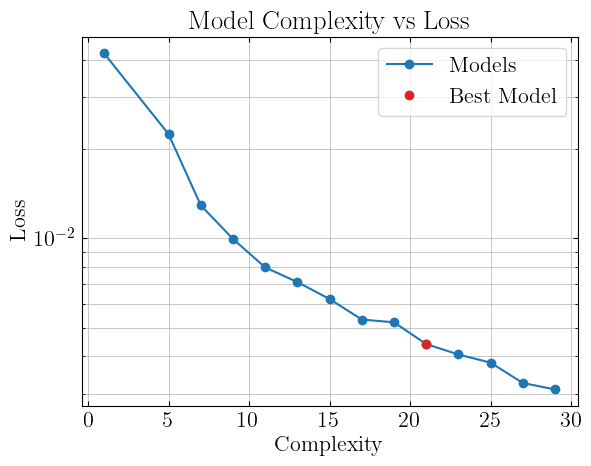

In [9]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=17.336506
Equation: x0

Model 1: Complexity=3, Loss=10.970768
Equation: 0.707982 / x2

Model 2: Complexity=5, Loss=6.463608
Equation: (x0 / x2) - x0

Model 3: Complexity=7, Loss=1.6179678
Equation: cube((x0 * 0.14444138) / x2)

Model 4: Complexity=9, Loss=1.3454857
Equation: square(((0.30030873 / x2) * x0) - 1.158415)

Model 5: Complexity=10, Loss=1.2691572
Equation: exp((x2 / (x0 * -0.024168313)) + 5.2291865)

Model 6: Complexity=12, Loss=1.0702667
Equation: exp((x2 / (x0 * -0.022665512)) + 5.349659) + 0.49018705

Model 7: Complexity=13, Loss=0.9106228
Equation: 0.07329351 / (tanh(x0 / (x2 * -4.6626453)) + 1.0027081)

Model 8: Complexity=15, Loss=0.7777737
Equation: (tanh(((x0 / x2) * 0.26197857) + -3.9486554) + 1.0405749) / 0.08046937

Model 9: Complexity=17, Loss=0.7290419
Equation: (tanh((((0.26954454 / x2) - -0.08305209) * x0) + -4.2676306) + 1.0422852) * 12.458228

Model 10: Complexity=18, Loss=0.6483391
Equation: (tanh(-7.7179785 - ((x0 + 1.8102227) *

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 12.286049*(tanh(2.1971498**x0*(-1*0.20958212 + 0.09817447/x2) - 2.8793967) + 1.0407348)
Loss: 0.10298812
Best model complexity: 21


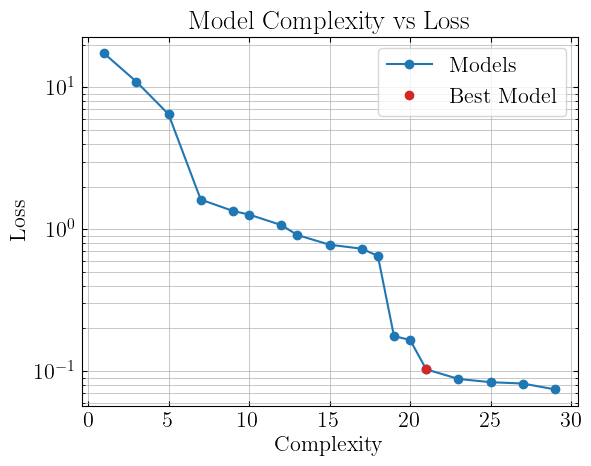

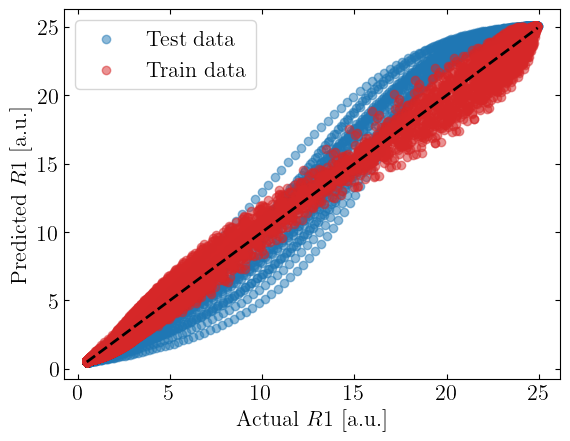

In [10]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=23.067108
Equation: 13.395134

Model 1: Complexity=3, Loss=12.926736
Equation: x2 * 22.923517

Model 2: Complexity=5, Loss=4.7029977
Equation: sqrt(x2) * 19.188335

Model 3: Complexity=7, Loss=1.7572738
Equation: 27.675972 / (x2 - (-0.66643566 / x2))

Model 4: Complexity=8, Loss=1.7327065
Equation: 22.337994 / exp(0.21269944 / x2)

Model 5: Complexity=9, Loss=0.91169906
Equation: (-0.22450759 / (cube(x2) + 0.013422608)) + 17.130672

Model 6: Complexity=11, Loss=0.91144127
Equation: ((-0.26643828 / (cube(x2) + 0.01546232)) - -18.022383) - x2

Model 7: Complexity=13, Loss=0.60405636
Equation: (-0.295283 / ((cube(x2) * sqrt(x0)) + 0.01805205)) + 17.26503

Model 8: Complexity=15, Loss=0.49019185
Equation: ((x0 + 3.919572) / (((cube(x2) * x0) * -17.341667) + -0.30363753)) + 17.189436

Model 9: Complexity=17, Loss=0.2406508
Equation: ((cube(x0) + 41.372154) / ((x0 * cube(x2 * -5.463892)) + -2.631623)) + 17.169928

Model 10: Complexity=18, Loss=0.2342051
Equation: 

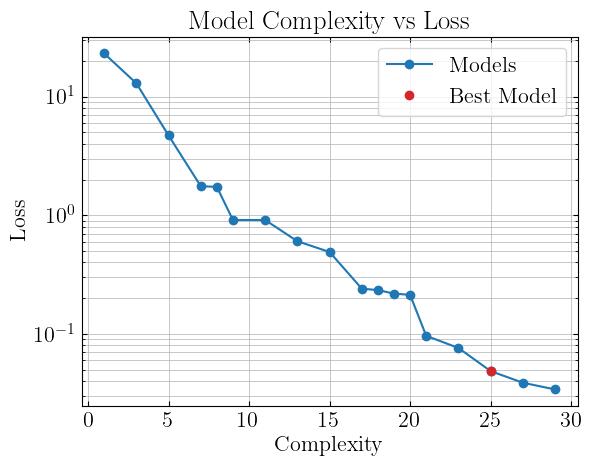

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 17.136093 + 32.153217/((x2*(-4.9186873) + (-0.06972878 + x2/x0)*((-x0 + x2)**3 + 0.43222344))**3 - 2.0073338)
Loss: 0.048651464
Best model complexity: 25


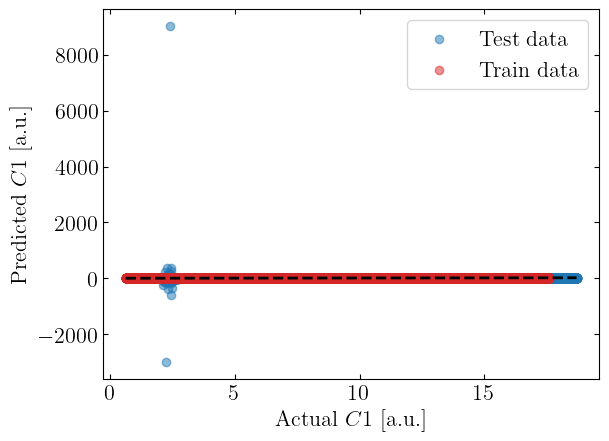

In [11]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.13626108
Equation: 2.7465668

Model 1: Complexity=5, Loss=0.005729038
Equation: (x1 * 0.037341524) + 2.3085792

Model 2: Complexity=7, Loss=0.003522808
Equation: (1.0262604 ^ x1) + 1.3468257

Model 3: Complexity=9, Loss=0.0024327333
Equation: (x2 * -0.21371873) + ((x1 * 0.03734647) + 2.4233272)

Model 4: Complexity=11, Loss=0.00020533388
Equation: ((1.0262628 ^ x1) + 1.4618124) - (x2 * 0.21418041)

Model 5: Complexity=13, Loss=4.3523178e-05
Equation: ((1.034097 ^ x1) + 2.4458973) * ((x2 * -0.05350382) + 0.7136552)

Model 6: Complexity=15, Loss=3.7144127e-05
Equation: sqrt(((1.0474416 ^ x1) + 1.4060591) * ((x2 * -0.36129096) + 2.5092132))

Model 7: Complexity=16, Loss=3.0834395e-05
Equation: log((1.0584812 ^ x1) + 3.2568824) * ((x2 * -0.12714012) + 1.6984559)

Model 8: Complexity=17, Loss=7.82531e-06
Equation: ((1.0270071 ^ x1) + 1.447367) + ((x2 * -0.2788384) + (x2 / (x1 + 8.353354)))

Model 9: Complexity=19, Loss=6.8401414e-06
Equation: (x2 * -0.27034587)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.0270071**x1 + x2*(-0.27034587) + x2/(x1*1.3710188 + 8.857316) + 1.447367
Loss: 6.8401414e-06
Best model complexity: 19


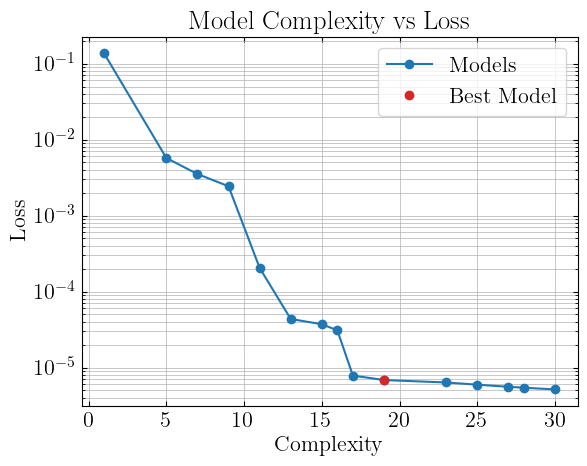

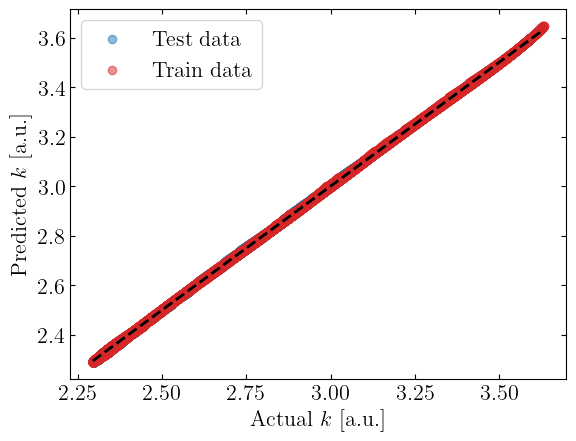

In [12]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.6788799
Equation: 1.2820385

Model 1: Complexity=3, Loss=0.343196
Equation: 1.8137901 - x2

Model 2: Complexity=5, Loss=0.1023517
Equation: (0.98946273 - x2) / 0.35357866

Model 3: Complexity=16, Loss=0.10230341
Equation: ((tanh(exp(0.12786761 - x2)) * 4.2256074) + -1.6519088) * 1.5710692

Model 4: Complexity=19, Loss=0.08844282
Equation: (square(0.5369758 - square(cos(x1) / -0.8763332)) + 2.4606001) - (x2 * 2.77889)

Model 5: Complexity=24, Loss=0.03386102
Equation: exp((x2 / -1.6206173) - ((x2 ^ 2.4474187) + tanh((x1 * 0.086219445) * x2))) * 3.0165088

Model 6: Complexity=26, Loss=0.02904233
Equation: (exp((x2 / -1.9725018) - ((x2 ^ 2.509441) + tanh((x1 * 0.05495062) * x2))) * 3.499888) + -0.44582832



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(x2/(-1.6206173) - (x2**2.4474187 + tanh(x1*0.086219445*x2)))*3.0165088
Loss: 0.03386102
Best model complexity: 24


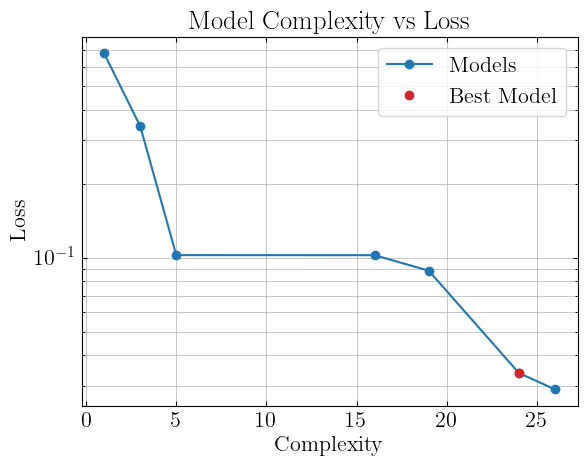

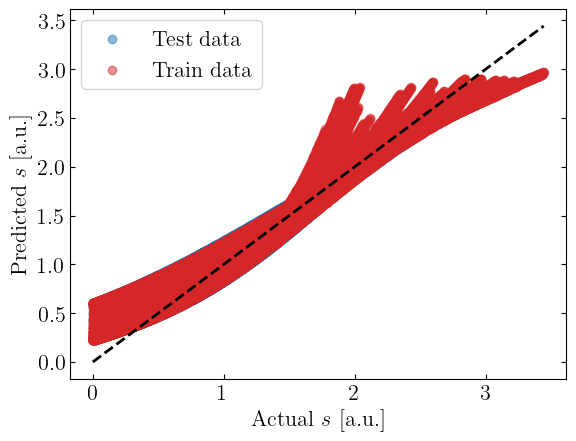

In [13]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(X_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = 10, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [14]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [15]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

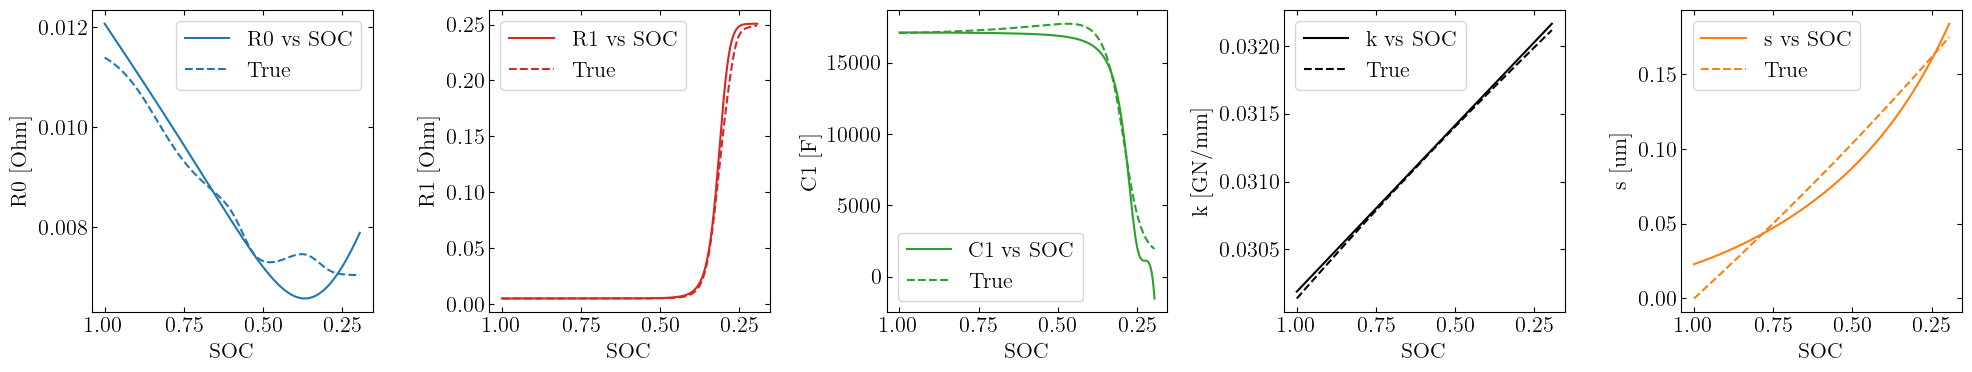

In [19]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        Y_true = traj[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 5, test = True)
plot_soc(MODEL_DICT, traj)

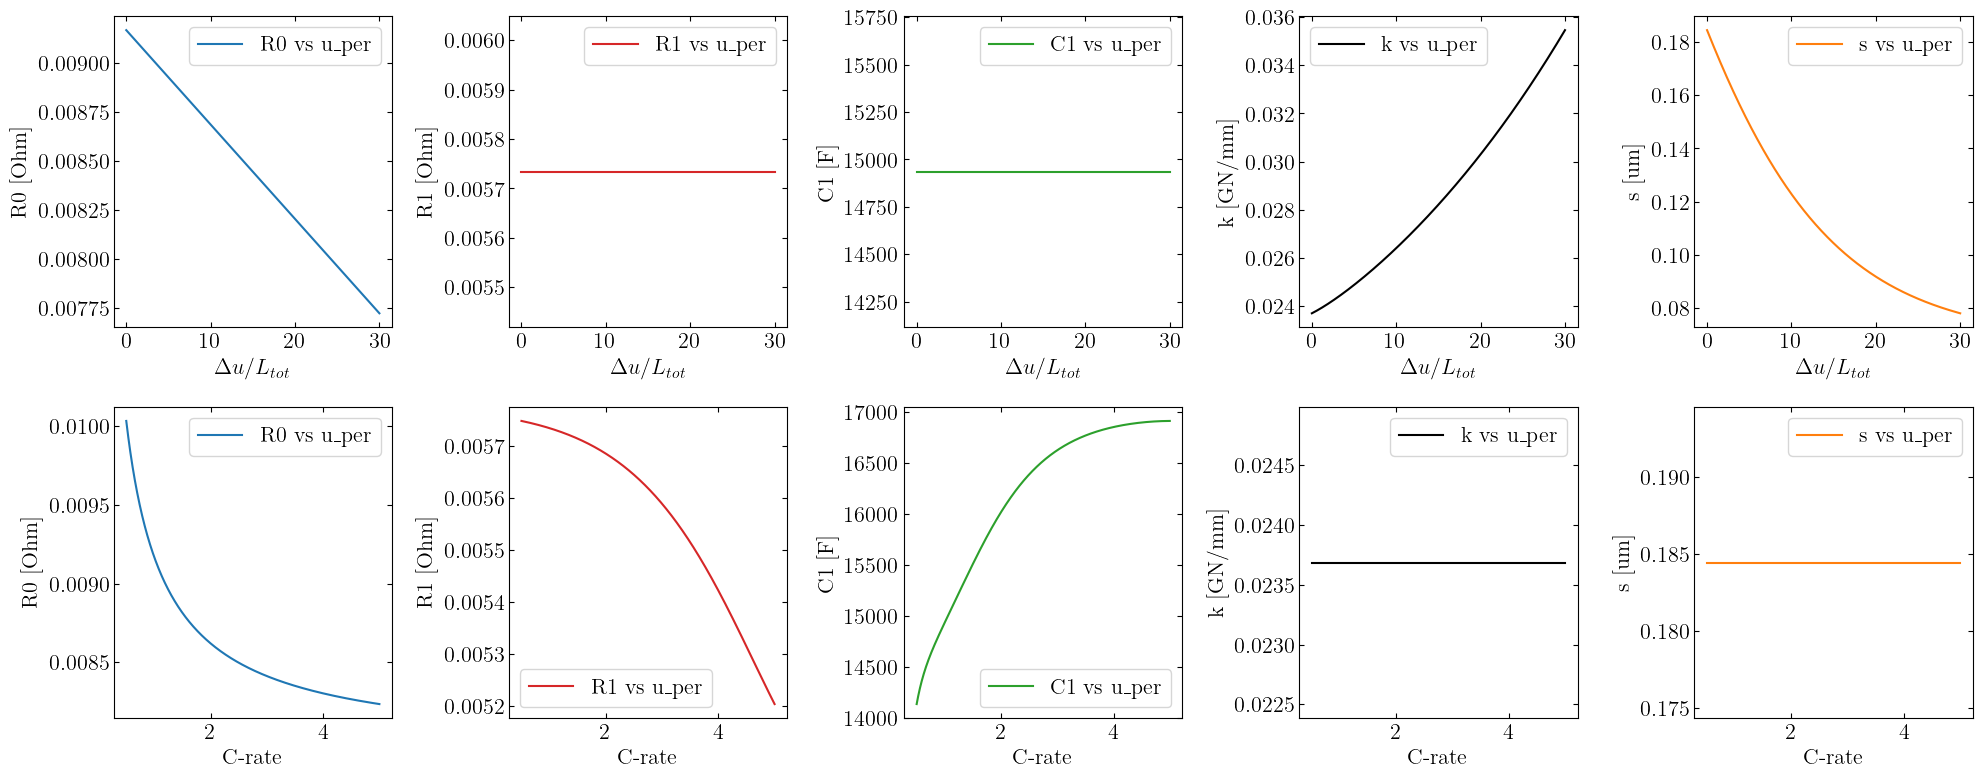

In [20]:
def plot_d(models):
    u_per = np.linspace(0,30,1000)
    C_fixed = 1
    C = np.linspace(0.5,5,1000)
    u_fixed = 0
    soc_fixed = 0.5
    X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
    X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
    f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
    for var in VARIABLES:
        model = models[var]
        Y_plot = model.predict(X_plot1) * REF_VALUES[var]
        ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
        ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[0,VARIABLES.index(var)].legend()
        Y_plot = model.predict(X_plot2) * REF_VALUES[var]
        ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
        ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
        ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[1,VARIABLES.index(var)].legend()
        
    plt.tight_layout()

plot_d(MODEL_DICT)


In [18]:
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')
    save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')